# DeDiff Stats for Fig05

In [1]:
# Load R Packages
library(fcexpr) # Reads FlowJo Workspace files
library(ggplot2)
library(cowplot)
library(ggpubr)
library(ggsci)
library(ggprism)
library(tidyr)
library(dplyr)


Attaching package: ‘ggpubr’




The following object is masked from ‘package:cowplot’:

    get_legend





Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# Set working directory
setwd("/home/dalbao/AlbaoRunx3Manuscript/flow/Fig04")

# Load flow processing functions (plot_padj for multiple-hypothesis-corrected comparisons)
source("/home/dalbao/AlbaoRunx3Manuscript/flow/scripts/flowProcessing.R")

# Load data
data <- read.csv("De-Diff-Stats-Data.csv")

data


Attaching package: ‘rstatix’




The following object is masked from ‘package:stats’:

    filter





Attaching package: ‘purrr’




The following objects are masked from ‘package:rlang’:

    %@%, flatten, flatten_chr, flatten_dbl, flatten_int, flatten_lgl,
    flatten_raw, invoke, splice




Experiment,ID,count,mock.count,exp.count,mock.TE,mock.DP,mock.MP,mock.EE,mock.Tcm,⋯,exp.TE,exp.DP,exp.MP,exp.EE,exp.Tcm,exp.Tpm,exp.Tem,exp.Tcf7,exp.CD62L,exp.Double
<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
shRunx3,Resac_M2.fcs,370,333,32,37.2,34.20,20.40,8.11,18.60,⋯,50.0,18.80,21.90,9.38,21.90,9.38,68.8,18.80,12.50,6.25
shRunx3,Spleen_M2.fcs,129,105,24,42.9,20.00,29.50,7.62,26.70,⋯,50.0,16.70,20.80,12.50,8.33,4.17,87.5,4.17,0.00,16.70
shRunx3,Spleen_M3.fcs,39,34,5,44.1,8.82,26.50,20.60,11.80,⋯,100.0,0.00,0.00,0.00,0.00,0.00,100.0,0.00,0.00,0.00
shRunx3,Spleen_M4.fcs,51,39,11,23.1,23.10,48.70,5.13,33.30,⋯,54.5,9.09,9.09,27.30,0.00,27.30,72.7,9.09,9.09,0.00
shRunx3,Spleen_M5.fcs,78,71,6,46.5,21.10,19.70,12.70,23.90,⋯,50.0,50.00,0.00,0.00,50.00,0.00,50.0,16.70,0.00,0.00
shRunx3,Spleen_M6.fcs,16,10,5,10.0,20.00,70.00,0.00,20.00,⋯,100.0,0.00,0.00,0.00,0.00,0.00,100.0,20.00,20.00,0.00
dAD,Spleen_Mouse1.fcs,361,333,15,24.9,35.40,36.30,3.30,22.50,⋯,60.0,13.30,13.30,13.30,6.67,6.67,80.0,40.00,6.67,13.30
dAD,Spleen_Mouse2.fcs,1080,1058,10,50.1,25.80,21.00,3.12,12.20,⋯,50.0,40.00,10.00,0.00,0.00,0.00,90.0,30.00,10.00,10.00
dAD,Spleen_Mouse3.fcs,1003,975,8,44.8,30.20,21.60,3.38,11.60,⋯,37.5,25.00,37.50,0.00,0.00,12.50,75.0,75.00,0.00,12.50


In [3]:
# Make ratio calculations
data$mock.ratio <- data$mock.count / data$count * 100
data$exp.ratio <- data$exp.count / data$count * 100

data

Experiment,ID,count,mock.count,exp.count,mock.TE,mock.DP,mock.MP,mock.EE,mock.Tcm,⋯,exp.MP,exp.EE,exp.Tcm,exp.Tpm,exp.Tem,exp.Tcf7,exp.CD62L,exp.Double,mock.ratio,exp.ratio
<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
shRunx3,Resac_M2.fcs,370,333,32,37.2,34.20,20.40,8.11,18.60,⋯,21.90,9.38,21.90,9.38,68.8,18.80,12.50,6.25,90.00000,8.6486486
shRunx3,Spleen_M2.fcs,129,105,24,42.9,20.00,29.50,7.62,26.70,⋯,20.80,12.50,8.33,4.17,87.5,4.17,0.00,16.70,81.39535,18.6046512
shRunx3,Spleen_M3.fcs,39,34,5,44.1,8.82,26.50,20.60,11.80,⋯,0.00,0.00,0.00,0.00,100.0,0.00,0.00,0.00,87.17949,12.8205128
shRunx3,Spleen_M4.fcs,51,39,11,23.1,23.10,48.70,5.13,33.30,⋯,9.09,27.30,0.00,27.30,72.7,9.09,9.09,0.00,76.47059,21.5686275
shRunx3,Spleen_M5.fcs,78,71,6,46.5,21.10,19.70,12.70,23.90,⋯,0.00,0.00,50.00,0.00,50.0,16.70,0.00,0.00,91.02564,7.6923077
shRunx3,Spleen_M6.fcs,16,10,5,10.0,20.00,70.00,0.00,20.00,⋯,0.00,0.00,0.00,0.00,100.0,20.00,20.00,0.00,62.50000,31.2500000
dAD,Spleen_Mouse1.fcs,361,333,15,24.9,35.40,36.30,3.30,22.50,⋯,13.30,13.30,6.67,6.67,80.0,40.00,6.67,13.30,92.24377,4.1551247
dAD,Spleen_Mouse2.fcs,1080,1058,10,50.1,25.80,21.00,3.12,12.20,⋯,10.00,0.00,0.00,0.00,90.0,30.00,10.00,10.00,97.96296,0.9259259
dAD,Spleen_Mouse3.fcs,1003,975,8,44.8,30.20,21.60,3.38,11.60,⋯,37.50,0.00,0.00,12.50,75.0,75.00,0.00,12.50,97.20837,0.7976072


In [4]:
#  Remove columns containing count
data <- data %>%
  select(-c(count, mock.count, exp.count))

# Then gather data to long format
data <- data %>%
  gather(key = "Condition", value = "Percent", -c(1:2))

In [5]:
data

Experiment,ID,Condition,Percent
<chr>,<chr>,<chr>,<dbl>
shRunx3,Resac_M2.fcs,mock.TE,37.20
shRunx3,Spleen_M2.fcs,mock.TE,42.90
shRunx3,Spleen_M3.fcs,mock.TE,44.10
shRunx3,Spleen_M4.fcs,mock.TE,23.10
shRunx3,Spleen_M5.fcs,mock.TE,46.50
shRunx3,Spleen_M6.fcs,mock.TE,10.00
dAD,Spleen_Mouse1.fcs,mock.TE,24.90
dAD,Spleen_Mouse2.fcs,mock.TE,50.10
dAD,Spleen_Mouse3.fcs,mock.TE,44.80


In [6]:
# Column condition contains two pieces of metadata separated by a dot
# We can separate them into two new columns called "Transduction" and "Population"
data <- data %>%
  separate(Condition, into = c("Transduction", "Population"), sep = "\\.", extra = "merge", fill = "right")

data

Experiment,ID,Transduction,Population,Percent
<chr>,<chr>,<chr>,<chr>,<dbl>
shRunx3,Resac_M2.fcs,mock,TE,37.20
shRunx3,Spleen_M2.fcs,mock,TE,42.90
shRunx3,Spleen_M3.fcs,mock,TE,44.10
shRunx3,Spleen_M4.fcs,mock,TE,23.10
shRunx3,Spleen_M5.fcs,mock,TE,46.50
shRunx3,Spleen_M6.fcs,mock,TE,10.00
dAD,Spleen_Mouse1.fcs,mock,TE,24.90
dAD,Spleen_Mouse2.fcs,mock,TE,50.10
dAD,Spleen_Mouse3.fcs,mock,TE,44.80


### Plot Ratios

In [7]:
# Use ggprism, base 12, not bold, and remove legend
theme <- theme_bw(      base_size = 14,
                        base_family = "sans",
                        #base_fontface = "plain"
                        ) +
    theme(  axis.text = element_text(size = 10),
            axis.title = element_text(size = 12),
            axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 12),
            axis.title.x = element_blank(),
            strip.text = element_text(size = 12),
            legend.position = "none",
            plot.title = element_text(size = 12),  # Set main title size
            panel.grid = element_blank())  # Remove gridlines

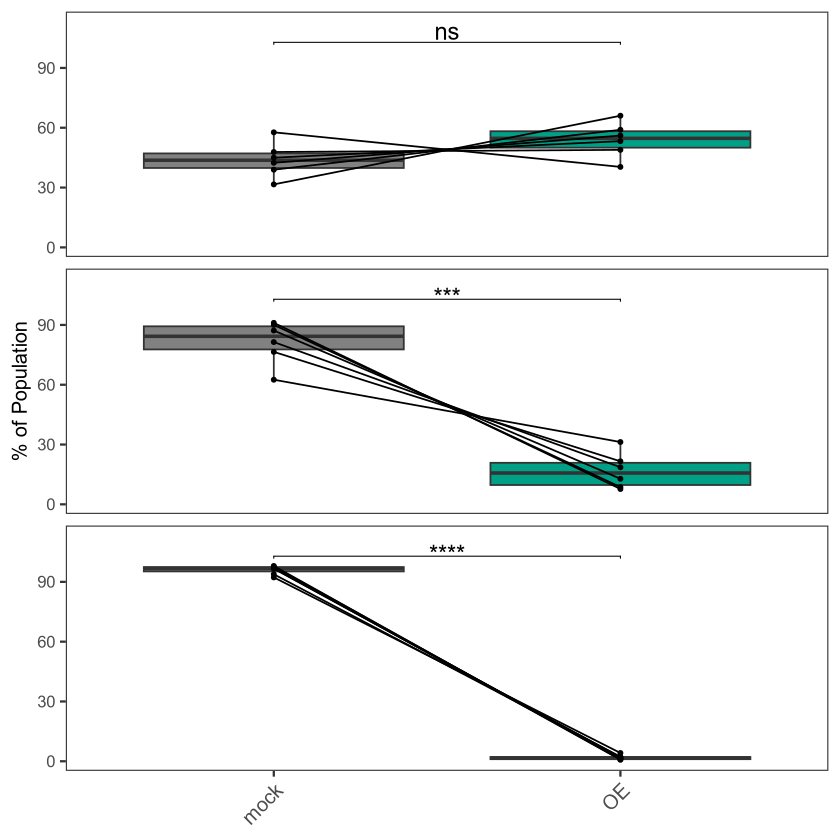

In [8]:
# Keep only Population == ratio
subset <- data %>%
    filter(Population == "ratio") %>%
    mutate(Transduction = factor(Transduction, levels = c("mock", "exp"))) %>%
    mutate(Experiment = factor(Experiment, levels = c("dVWRPY", "shRunx3", "dAD")))

# Create a default theme
colors <- c("mock" = "#808180", "exp" = "#00A087")

# mock and OE come from the SAME mouse, so the test is paired; ID is the mouse
# identifier plot_padj() uses to validate and enforce that pairing.
# adjust_scope = "total" because the family of tests shown in this figure is the
# one mock-vs-OE comparison in each of the three experiments -- with only one
# comparison per facet, the default "intrafacet" scope would correct nothing.
plot.stat.df <- plot_padj(
    data = subset,
    comparisons = list(c("mock", "exp")),
    y_col = "Percent",
    x_col = "Transduction",
    facet_col = "Experiment",
    id_col = "ID",
    paired = TRUE,
    adjust_scope = "total"
) %>%
    # Panels share one fixed y scale (ylim below), so put every bracket at the
    # same height rather than at plot_padj()'s per-facet default.
    mutate(y.position = max(subset$Percent) * 1.05)

# Save comparison statistics (p, p.adj, fold changes) to CSV
write.csv(plot.stat.df, "250415-DeDiff-Ratio-stats.csv", row.names = FALSE)

p <- ggplot(subset, aes(x = Transduction, y = Percent, fill = Transduction)) +
    geom_boxplot(outliers = FALSE) +
    geom_point(size=1) +
    geom_line(aes(group = ID)) +
    facet_wrap(~ Experiment, ncol = 1) +  # Set number of columns
    stat_pvalue_manual(
        plot.stat.df,
        label = "p.adj.signif",   # adjusted p-value stars
        tip.length = 0.01,
        size = 5,
        inherit.aes = FALSE       # important fix
    ) +
    ylim(c(min(subset$Percent) * 0.99, max(subset$Percent) * 1.15)) +
    scale_fill_manual(values = colors) +
    scale_x_discrete(labels = c("mock" = "mock", "exp" = "OE")) +  # Rename categories
    ylab("% of Population") +
    theme +
    theme(strip.text = element_blank())  # Remove facet titles

#pdf("Test2.pdf")
print(p)

In [9]:
# Save as PDF
pdf("De-DiffRatios.pdf", width = 1.5, height = 5)
print(p)
dev.off()

pdf 
  2

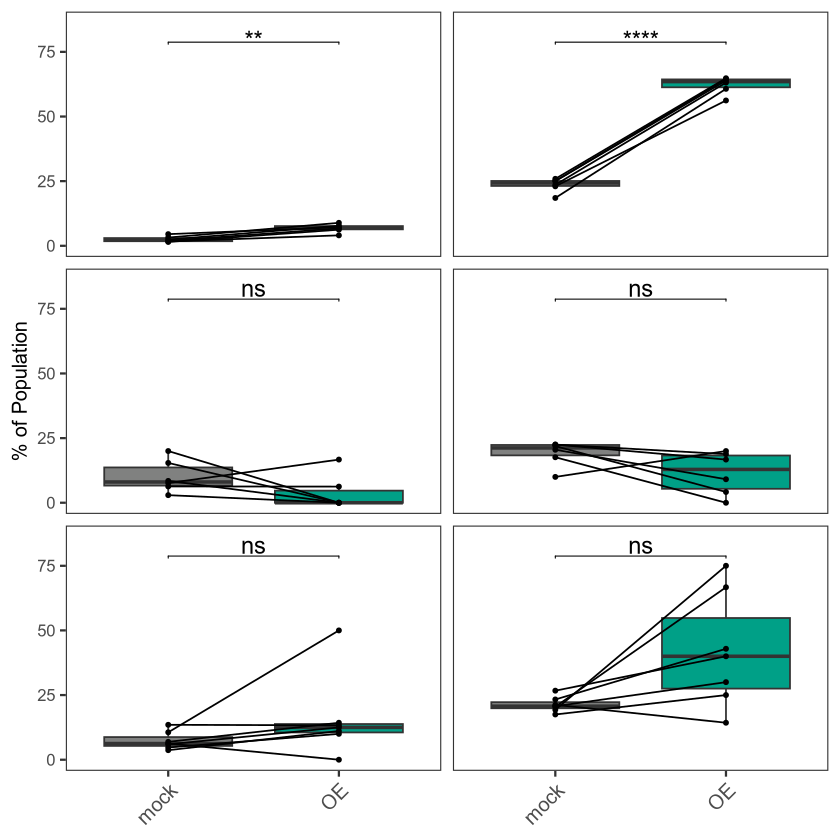

In [10]:
# Keep only Population == Tcf7 or Double
subset <- data %>%
    filter(Population %in% c("Tcf7", "Double")) %>%
    mutate(Transduction = factor(Transduction, levels = c("mock", "exp"))) %>%
    mutate(Experiment = factor(Experiment, levels = c("dVWRPY", "shRunx3", "dAD"))) %>%
    # plot_padj() takes a single faceting column, but the plot facets on two.
    # Collapse them into one key for the test, then split it back apart so
    # stat_pvalue_manual() can still map each bracket to its panel.
    mutate(Facet = interaction(Experiment, Population, sep = "___", drop = TRUE))

# Create a default theme
colors <- c("mock" = "#808180", "exp" = "#00A087")

# Paired by mouse (ID); BH across all 6 mock-vs-OE tests drawn in this figure.
plot.stat.df <- plot_padj(
    data = subset,
    comparisons = list(c("mock", "exp")),
    y_col = "Percent",
    x_col = "Transduction",
    facet_col = "Facet",
    id_col = "ID",
    paired = TRUE,
    adjust_scope = "total"
) %>%
    separate(Facet, into = c("Experiment", "Population"), sep = "___") %>%
    mutate(Experiment = factor(Experiment, levels = levels(subset$Experiment)),
           # Panels share one fixed y scale, so all brackets sit at one height
           y.position = max(subset$Percent) * 1.05)

# Save comparison statistics (p, p.adj, fold changes) to CSV
write.csv(plot.stat.df, "250415-DeDiff-TcmTcf7-stats.csv", row.names = FALSE)

p <- ggplot(subset, aes(x = Transduction, y = Percent, fill = Transduction)) +
    geom_boxplot(outliers = FALSE) +
    geom_point(size=1) +
    geom_line(aes(group = ID)) +
    facet_wrap(~ Experiment + Population, ncol = 2) +  # Set number of columns
    stat_pvalue_manual(
        plot.stat.df,
        label = "p.adj.signif",   # adjusted p-value stars
        tip.length = 0.01,
        size = 5,
        inherit.aes = FALSE       # important fix
    ) +
    ylim(c(min(subset$Percent) * 0.99, max(subset$Percent) * 1.15)) +
    scale_fill_manual(values = colors) +
    scale_x_discrete(labels = c("mock" = "mock", "exp" = "OE")) +  # Rename categories
    ylab("% of Population") +
    theme +
    theme(strip.text = element_blank())  # Remove facet titles

#pdf("Test2.pdf")
print(p)

In [11]:
subset

Experiment,ID,Transduction,Population,Percent,Facet
<fct>,<chr>,<fct>,<chr>,<dbl>,<fct>
shRunx3,Resac_M2.fcs,mock,Tcf7,22.50,shRunx3___Tcf7
shRunx3,Spleen_M2.fcs,mock,Tcf7,21.90,shRunx3___Tcf7
shRunx3,Spleen_M3.fcs,mock,Tcf7,17.60,shRunx3___Tcf7
shRunx3,Spleen_M4.fcs,mock,Tcf7,20.50,shRunx3___Tcf7
shRunx3,Spleen_M5.fcs,mock,Tcf7,22.50,shRunx3___Tcf7
shRunx3,Spleen_M6.fcs,mock,Tcf7,10.00,shRunx3___Tcf7
dAD,Spleen_Mouse1.fcs,mock,Tcf7,26.70,dAD___Tcf7
dAD,Spleen_Mouse2.fcs,mock,Tcf7,20.70,dAD___Tcf7
dAD,Spleen_Mouse3.fcs,mock,Tcf7,19.30,dAD___Tcf7


In [12]:
# Save as PDF
pdf("De-DiffTcm.pdf", width = 3, height = 5)
print(p)
dev.off()

pdf 
  2

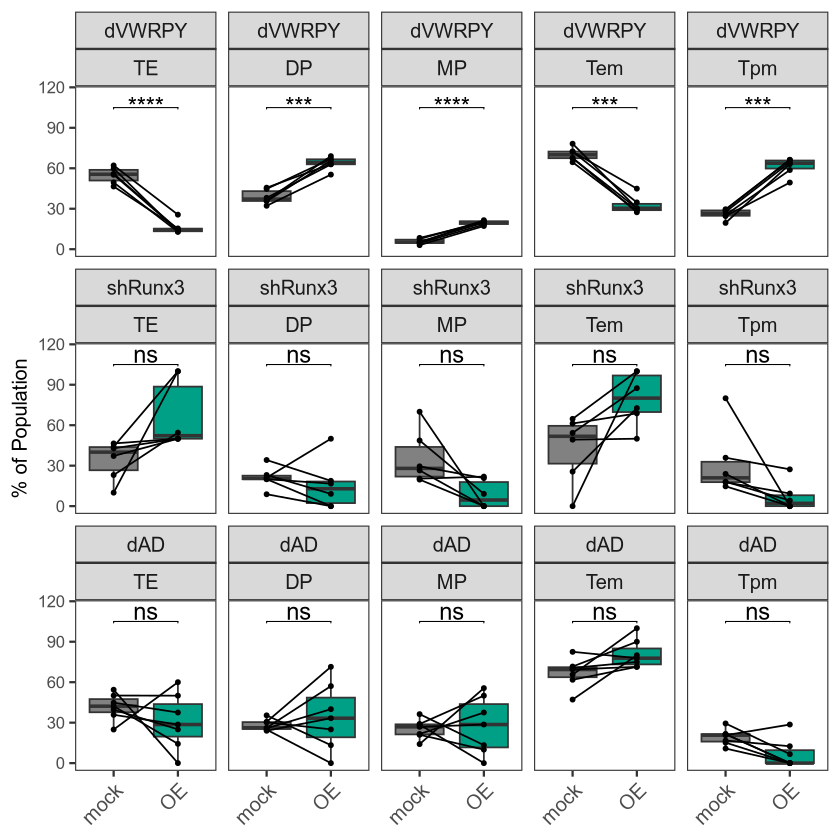

In [13]:
# Keep only the differentiation subsets
subset <- data %>%
    filter(Population %in% c("TE", "DP", "MP", "Tem", "Tpm")) %>%
    mutate(Population = factor(Population, levels = c("TE", "DP", "MP", "Tem", "Tpm"))) %>%
    mutate(Transduction = factor(Transduction, levels = c("mock", "exp"))) %>%
    mutate(Experiment = factor(Experiment, levels = c("dVWRPY", "shRunx3", "dAD"))) %>%
    # Single test-side facet key standing in for the plot's two facet variables
    mutate(Facet = interaction(Experiment, Population, sep = "___", drop = TRUE))

# Create a default theme
colors <- c("mock" = "#808180", "exp" = "#00A087")

# Paired by mouse (ID); BH across all 15 mock-vs-OE tests drawn in this figure.
plot.stat.df <- plot_padj(
    data = subset,
    comparisons = list(c("mock", "exp")),
    y_col = "Percent",
    x_col = "Transduction",
    facet_col = "Facet",
    id_col = "ID",
    paired = TRUE,
    adjust_scope = "total"
) %>%
    separate(Facet, into = c("Experiment", "Population"), sep = "___") %>%
    mutate(Experiment = factor(Experiment, levels = levels(subset$Experiment)),
           Population = factor(Population, levels = levels(subset$Population)),
           # Panels share one fixed y scale, so all brackets sit at one height
           y.position = max(subset$Percent) * 1.05)

# Save comparison statistics (p, p.adj, fold changes) to CSV
write.csv(plot.stat.df, "250415-DeDiff-Subsets-stats.csv", row.names = FALSE)

p <- ggplot(subset, aes(x = Transduction, y = Percent, fill = Transduction)) +
    geom_boxplot(outliers = FALSE) +
    geom_point(size=1) +
    geom_line(aes(group = ID)) +
    facet_wrap(~ Experiment + Population, ncol = 5) +  # Set number of columns
    stat_pvalue_manual(
        plot.stat.df,
        label = "p.adj.signif",   # adjusted p-value stars
        tip.length = 0.01,
        size = 5,
        inherit.aes = FALSE       # important fix
    ) +
    ylim(c(min(subset$Percent) * 0.99, max(subset$Percent) * 1.15)) +
    scale_fill_manual(values = colors) +
    scale_x_discrete(labels = c("mock" = "mock", "exp" = "OE")) +  # Rename categories
    ylab("% of Population") +
    theme
    # theme(strip.text = element_blank())  # Remove facet titles

#pdf("Test2.pdf")
print(p)

In [14]:
pdf("Test.pdf", width = 10, height = 10)
print(p)
dev.off()

pdf 
  2

In [15]:
# Ragged Apply mean by Experiment, Transduction and Population
summary <- data %>%
    group_by(Experiment, Transduction, Population) %>%
    summarise(mean = mean(Percent), sd = sd(Percent), n = n()) %>%
    ungroup()

`summarise()` has grouped output by 'Experiment', 'Transduction'. You can
override using the `.groups` argument.


In [16]:
summary

Experiment,Transduction,Population,mean,sd,n
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>
dAD,exp,CD62L,4.4242857,5.9436068,7
dAD,exp,DP,34.3000000,24.6093478,7
dAD,exp,Double,15.8857143,15.7815745,7
dAD,exp,EE,7.0571429,9.8020163,7
dAD,exp,MP,27.8571429,21.0567374,7
dAD,exp,TE,30.7714286,20.5163930,7
dAD,exp,Tcf7,41.9857143,22.0007143,7
dAD,exp,Tcm,0.9528571,2.5210230,7
dAD,exp,Tem,80.8000000,10.5930795,7


In [17]:
summary[summary$Population == "Double", ]

Experiment,Transduction,Population,mean,sd,n
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>
dAD,exp,Double,15.885714,15.781575,7
dAD,mock,Double,7.375714,3.464197,7
dVWRPY,exp,Double,6.808333,1.636611,6
dVWRPY,mock,Double,2.545000,1.133997,6
shRunx3,exp,Double,3.825000,6.784818,6
shRunx3,mock,Double,10.120000,6.334038,6


In [18]:
summary[summary$Population == "Tcf7", ]

Experiment,Transduction,Population,mean,sd,n
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>
dAD,exp,Tcf7,41.98571,22.000714,7
dAD,mock,Tcf7,21.31429,2.961097,7
dVWRPY,exp,Tcf7,62.20000,3.286335,6
dVWRPY,mock,Tcf7,23.51667,2.676876,6
shRunx3,exp,Tcf7,11.46000,8.298884,6
shRunx3,mock,Tcf7,19.16667,4.857022,6


### Percent of all Transferred

In [19]:
# From data, keep only Population = "ratio", "Double" or "Tcf7"
all <- data %>%
    filter(Population %in% c("ratio", "Double", "Tcf7")) %>%
    mutate(Transduction = factor(Transduction, levels = c("mock", "exp"))) %>%
    mutate(Experiment = factor(Experiment, levels = c("dVWRPY", "shRunx3", "dAD")))

In [20]:
all

Experiment,ID,Transduction,Population,Percent
<fct>,<chr>,<fct>,<chr>,<dbl>
shRunx3,Resac_M2.fcs,mock,Tcf7,22.50
shRunx3,Spleen_M2.fcs,mock,Tcf7,21.90
shRunx3,Spleen_M3.fcs,mock,Tcf7,17.60
shRunx3,Spleen_M4.fcs,mock,Tcf7,20.50
shRunx3,Spleen_M5.fcs,mock,Tcf7,22.50
shRunx3,Spleen_M6.fcs,mock,Tcf7,10.00
dAD,Spleen_Mouse1.fcs,mock,Tcf7,26.70
dAD,Spleen_Mouse2.fcs,mock,Tcf7,20.70
dAD,Spleen_Mouse3.fcs,mock,Tcf7,19.30


In [21]:
# Spread all Percent by Population
all <- all %>%
    spread(key = Population, value = Percent)

In [22]:
all

Experiment,ID,Transduction,Double,ratio,Tcf7
<fct>,<chr>,<fct>,<dbl>,<dbl>,<dbl>
dVWRPY,Spleen_VW01.fcs,mock,4.51,47.8436658,25.10
dVWRPY,Spleen_VW01.fcs,exp,7.16,48.9218329,64.50
dVWRPY,Spleen_VW02.fcs,mock,3.19,31.5945465,25.90
dVWRPY,Spleen_VW02.fcs,exp,8.89,66.0343806,64.80
dVWRPY,Spleen_VW03.fcs,mock,2.40,44.9954914,23.60
dVWRPY,Spleen_VW03.fcs,exp,7.78,53.2912534,63.10
dVWRPY,Spleen_VW04.fcs,mock,1.96,57.7097506,23.00
dVWRPY,Spleen_VW04.fcs,exp,6.74,40.3628118,56.20
dVWRPY,Spleen_VW05.fcs,mock,1.50,42.4178155,18.50


In [23]:
# Make new row DoubleAll and Tcf7All
all$DoubleAll <- (all$Double * all$ratio) / 100
all$Tcf7All   <- (all$Tcf7 * all$ratio) / 100

# Remove Double, ratio and Tcf7 column
# Then gather data to long format
all <- all %>%
    select(-c(ratio, Double, Tcf7)) %>%
    gather(key = "Population", value = "Percent", -c(1:3))

all

Experiment,ID,Transduction,Population,Percent
<fct>,<chr>,<fct>,<chr>,<dbl>
dVWRPY,Spleen_VW01.fcs,mock,DoubleAll,2.15774933
dVWRPY,Spleen_VW01.fcs,exp,DoubleAll,3.50280323
dVWRPY,Spleen_VW02.fcs,mock,DoubleAll,1.00786603
dVWRPY,Spleen_VW02.fcs,exp,DoubleAll,5.87045643
dVWRPY,Spleen_VW03.fcs,mock,DoubleAll,1.07989179
dVWRPY,Spleen_VW03.fcs,exp,DoubleAll,4.14605951
dVWRPY,Spleen_VW04.fcs,mock,DoubleAll,1.13111111
dVWRPY,Spleen_VW04.fcs,exp,DoubleAll,2.72045351
dVWRPY,Spleen_VW05.fcs,mock,DoubleAll,0.63626723


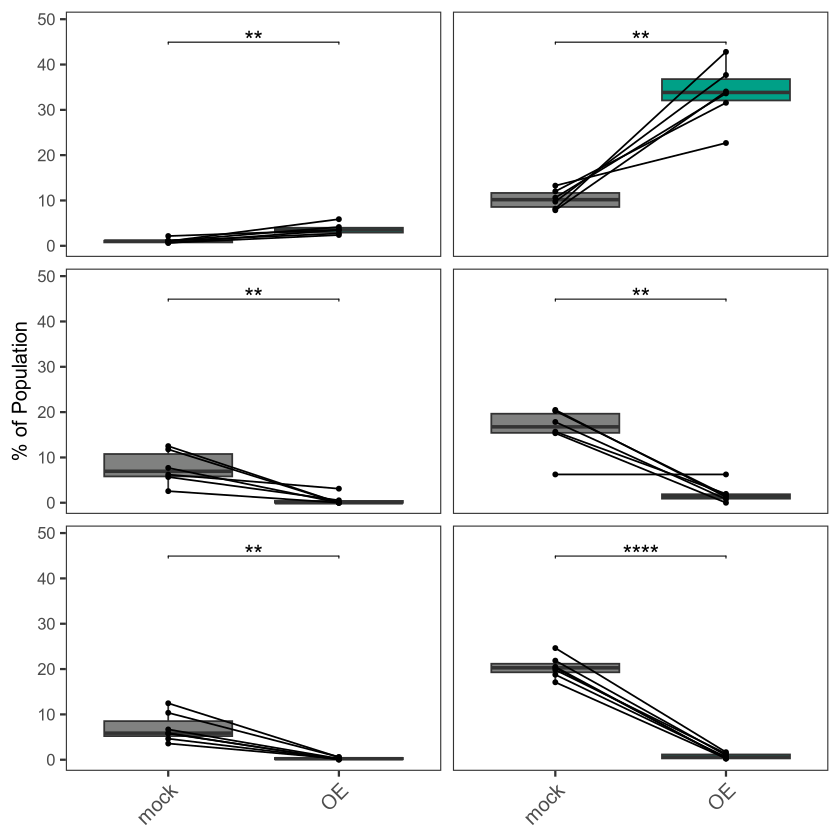

In [24]:
# Percent-of-all-transferred version of the Tcf7/Double panels
subset <- all %>%
    # Single test-side facet key standing in for the plot's two facet variables
    mutate(Facet = interaction(Experiment, Population, sep = "___", drop = TRUE))

# Create a default theme
colors <- c("mock" = "#808180", "exp" = "#00A087")

# Paired by mouse (ID); BH across all 6 mock-vs-OE tests drawn in this figure.
plot.stat.df <- plot_padj(
    data = subset,
    comparisons = list(c("mock", "exp")),
    y_col = "Percent",
    x_col = "Transduction",
    facet_col = "Facet",
    id_col = "ID",
    paired = TRUE,
    adjust_scope = "total"
) %>%
    separate(Facet, into = c("Experiment", "Population"), sep = "___") %>%
    mutate(Experiment = factor(Experiment, levels = levels(subset$Experiment)),
           # Panels share one fixed y scale, so all brackets sit at one height
           y.position = max(subset$Percent) * 1.05)

# Save comparison statistics (p, p.adj, fold changes) to CSV
write.csv(plot.stat.df, "250415-DeDiff-AllTransferred-stats.csv", row.names = FALSE)

p <- ggplot(subset, aes(x = Transduction, y = Percent, fill = Transduction)) +
    geom_boxplot(outliers = FALSE) +
    geom_point(size=1) +
    geom_line(aes(group = ID)) +
    facet_wrap(~ Experiment + Population, ncol = 2) +  # Set number of columns
    stat_pvalue_manual(
        plot.stat.df,
        label = "p.adj.signif",   # adjusted p-value stars
        tip.length = 0.01,
        size = 5,
        inherit.aes = FALSE       # important fix
    ) +
    ylim(c(min(subset$Percent) * 0.99, max(subset$Percent) * 1.15)) +
    scale_fill_manual(values = colors) +
    scale_x_discrete(labels = c("mock" = "mock", "exp" = "OE")) +  # Rename categories
    ylab("% of Population") +
    theme +
    theme(strip.text = element_blank())  # Remove facet titles

#pdf("Test2.pdf")
print(p)

In [25]:
# Save as PDF
pdf("De-DiffTcm-AllCounts.pdf", width = 3, height = 5)
print(p)
dev.off()

pdf 
  2

In [26]:
# Ragged Apply mean by Experiment, Transduction and Population
summary <- all %>%
    group_by(Experiment, Transduction, Population) %>%
    summarise(mean = mean(Percent), sd = sd(Percent), n = n()) %>%
    ungroup()

`summarise()` has grouped output by 'Experiment', 'Transduction'. You can
override using the `.groups` argument.


In [27]:
summary

Experiment,Transduction,Population,mean,sd,n
<fct>,<fct>,<chr>,<dbl>,<dbl>,<int>
dVWRPY,mock,DoubleAll,1.1132091,0.5533049,6
dVWRPY,mock,Tcf7All,10.2789103,2.1292102,6
dVWRPY,exp,DoubleAll,3.6871757,1.2395240,6
dVWRPY,exp,Tcf7All,33.7325016,6.7025210,6
shRunx3,mock,DoubleAll,7.7354233,3.8043554,6
shRunx3,mock,Tcf7All,15.9710685,5.2357533,6
shRunx3,exp,DoubleAll,0.6079195,1.2432290,6
shRunx3,exp,Tcf7All,1.9828273,2.2005730,6
dAD,mock,DoubleAll,7.0470490,3.1937810,7


# Rechallenge

In [28]:
rechallenge <- read.csv("dVW-Rechallenge.csv")

rechallenge

ID,primary.TE,primary.DP,primary.MP,primary.EE,primary.Tcm,primary.Tpm,primary.Tem,mock.TE,mock.DP,⋯,mock.Tcm,mock.Tpm,mock.Tem,dVWRPY.TE,dVWRPY.DP,dVWRPY.MP,dVWRPY.EE,dVWRPY.Tcm,dVWRPY.Tpm,dVWRPY.Tem
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2aryD7Sp-VW_M1.fcs,50.7,2.93,6.61,39.8,28.9,49.6,13.8,96.4,1.53,⋯,1.34,20.2,75.2,74.6,19.5,2.39,3.56,7.67,43.8,43.5
2aryD7Sp-VW_M2.fcs,56.3,3.80,4.47,35.4,22.7,53.4,15.4,94.4,1.51,⋯,2.55,26.8,67.6,84.0,11.9,0.85,3.21,8.88,41.6,44.3
2aryD7Sp-VW_M3.fcs,52.2,3.91,6.57,37.3,30.4,46.0,12.7,93.3,2.23,⋯,4.16,37.1,53.4,80.4,12.2,2.05,5.32,9.36,46.1,38.5
2aryD7Sp-VW_M4.fcs,51.2,5.04,6.65,37.1,27.0,50.3,13.3,89.9,2.84,⋯,3.22,30.7,62.0,77.6,17.4,1.38,3.65,10.10,41.9,42.7
2aryD7Sp-VW_M5.fcs,65.6,4.27,4.54,25.6,24.1,51.1,16.9,94.6,2.17,⋯,4.11,31.0,60.5,83.2,14.3,0.63,1.90,7.18,40.4,46.7


In [29]:
# Gather rechallenge
rechallenge <- rechallenge %>%
    gather(key = "Condition", value = "Percent", -c(1))

# Condition contains two pieces of metadata separated by a dot
# We can separate them into two new columns called "Condition" and "Population"
rechallenge <- rechallenge %>%
    separate(Condition, into = c("Condition", "Population"), sep = "\\.", extra = "merge", fill = "right")

rechallenge

ID,Condition,Population,Percent
<chr>,<chr>,<chr>,<dbl>
2aryD7Sp-VW_M1.fcs,primary,TE,50.70
2aryD7Sp-VW_M2.fcs,primary,TE,56.30
2aryD7Sp-VW_M3.fcs,primary,TE,52.20
2aryD7Sp-VW_M4.fcs,primary,TE,51.20
2aryD7Sp-VW_M5.fcs,primary,TE,65.60
2aryD7Sp-VW_M1.fcs,primary,DP,2.93
2aryD7Sp-VW_M2.fcs,primary,DP,3.80
2aryD7Sp-VW_M3.fcs,primary,DP,3.91
2aryD7Sp-VW_M4.fcs,primary,DP,5.04


In [30]:
# Keep only Tcm, Tpm and Tem in Population into subset df
# Then factorialize
subset <- rechallenge %>%
    filter(Population %in% c("Tcm", "Tpm", "Tem")) %>%
    mutate(Condition = factor(Condition, levels = c("mock", "dVWRPY", "primary"))) %>%
    mutate(Population = factor(Population, levels = c("Tcm", "Tpm", "Tem")))

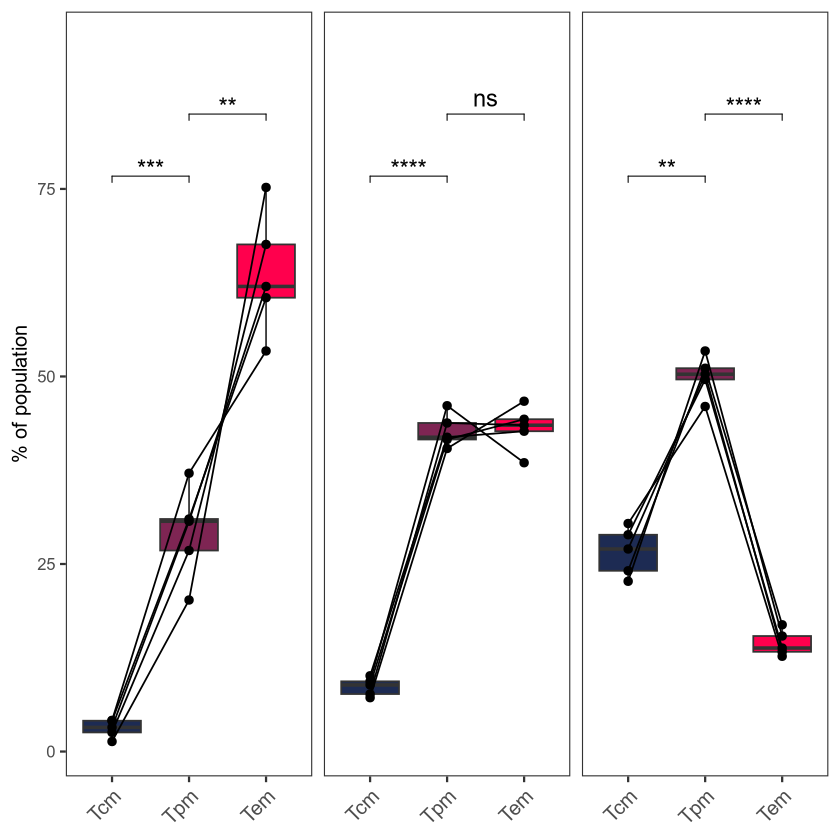

In [31]:
# Tcm/Tpm/Tem are repeated measures on the SAME mouse, so both comparisons are
# paired on ID. BH across all 6 tests drawn in this figure (2 per condition).
plot.stat.df <- plot_padj(
    data = subset,
    comparisons = list(c("Tcm", "Tpm"), c("Tpm", "Tem")),
    y_col = "Percent",
    x_col = "Population",
    facet_col = "Condition",
    id_col = "ID",
    paired = TRUE,
    adjust_scope = "total"
) %>%
    # Panels share one fixed y scale (ylim below), so stack the two brackets at
    # the same two heights in every panel instead of per-facet defaults.
    mutate(y.position = max(subset$Percent) * (1.02 + 0.11 * (comparison_id - 1)))

# Save comparison statistics (p, p.adj, fold changes) to CSV
write.csv(plot.stat.df, "250415-DeDiff-Rechallenge-stats.csv", row.names = FALSE)

p <- ggplot(subset, aes(x = Population, y = Percent, fill = Population)) +
    geom_boxplot(outliers = FALSE) +
    geom_point(size=2) +
    geom_line(aes(group = ID)) +
    facet_wrap(~ Condition, ncol = 3) +  # Set number of columns
    stat_pvalue_manual(
        plot.stat.df,
        label = "p.adj.signif",   # adjusted p-value stars
        tip.length = 0.01,
        size = 5,
        inherit.aes = FALSE       # important fix
    ) +
    ylim(c(min(subset$Percent) * 0.99, max(subset$Percent) * 1.25)) +
    scale_fill_manual(values = c("Tcm" = "#1D2B53", "Tpm" = "#7E2553", "Tem" = "#FF004D")) +
    ylab("% of population") +
    theme +
    theme(strip.text = element_blank())  # Remove facet titles

print(p)

In [32]:
pdf("Rechallenge-dVW-Stats.pdf", width = 4, height = 2)
print(p)
dev.off()

pdf 
  2